## Primeiro Modelo sem processar os dados

### Imports

In [23]:
import os
import json
import copy
import time
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, RandomSampler, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    auc,
    average_precision_score,
    precision_recall_curve,
)
from tqdm import tqdm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Cuda

In [24]:
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
    print("WARNING: Using CPU")

CUDA available: True
GPU: NVIDIA RTX 6000 Ada Generation
VRAM: 50.9 GB


### Carregar os dados

In [25]:
DATA_ROOT = "/mounts/mecd-ap-g5/data"
PROCESSED_IMAGES_DIR = os.path.join(DATA_ROOT, "MIQR-CC-Dataset/processed")
METADATA_PATH = os.path.join(DATA_ROOT, "MIQR-CC-Dataset/metadata.csv")

df = pd.read_csv(METADATA_PATH)
print("\n" + "=" * 60)
print("RAW DATASET INFO")
print("=" * 60)
print(f"Total samples: {len(df)}")


RAW DATASET INFO
Total samples: 19317


In [26]:
EXCLUDED_LABELS = {'unlabeled', 'unlabelled', 'unlabbeled'}

print("\nLabels found in metadata.csv:")
print(df['Label'].value_counts(dropna=False))

keep_mask = df['Keep'].astype(str).str.strip().str.lower().eq('keep')
label_mask = ~df['Label'].astype(str).str.strip().str.lower().isin(EXCLUDED_LABELS)

df_filtered = df[keep_mask & label_mask].copy()

print(f"\nAfter filtering (Keep == 'Keep' and Label not in {sorted(EXCLUDED_LABELS)}): {len(df_filtered)} samples")

print(f"\nLabel distribution after filtering:")
label_counts = df_filtered['Label'].value_counts()
for label, count in label_counts.items():
    print(f"   {label}: {count} ({count/len(df_filtered)*100:.1f}%)")

print(f"\nLabel by Image Type:")
print(pd.crosstab(df_filtered['Label'], df_filtered['image_type']))

print(f"\nAll samples have Keep == 'Keep': {df_filtered['Keep'].astype(str).str.strip().str.lower().eq('keep').all()}")
print(f"All samples are not unlabeled: {~df_filtered['Label'].astype(str).str.strip().str.lower().isin(EXCLUDED_LABELS).any()}")


Labels found in metadata.csv:
Label
Unlabelled             13798
Lithiasis               2651
Malignant Stricture     1281
Normal                  1012
Biliary Leaks            361
Benign Stricture         214
Name: count, dtype: int64

After filtering (Keep == 'Keep' and Label not in ['unlabbeled', 'unlabeled', 'unlabelled']): 1568 samples

Label distribution after filtering:
   Lithiasis: 726 (46.3%)
   Malignant Stricture: 329 (21.0%)
   Normal: 299 (19.1%)
   Biliary Leaks: 151 (9.6%)
   Benign Stricture: 63 (4.0%)

Label by Image Type:
image_type             S   V
Label                       
Benign Stricture      63   0
Biliary Leaks        146   5
Lithiasis            712  14
Malignant Stricture  324   5
Normal               276  23

All samples have Keep == 'Keep': True
All samples are not unlabeled: True


### Model comparison plan

The benchmark should stay as image classification because the metadata provides labels, not masks. To avoid patient leakage and to keep both image types represented, the split below will be patient-level and the training loop will use class balancing instead of removing the rare V images.

Models like Attention U-Net, U-Net, UNesT, and SwinUNETR are segmentation-first architectures and usually need masks or volumetric inputs. If those annotations become available later, we can extend this notebook with a true MONAI segmentation benchmark.

### Prepare the benchmark split

In [27]:
SEED = 42
IMG_SIZE = 320
BATCH_SIZE = 32
NUM_WORKERS = 8
NUM_EPOCHS = 20
PATIENCE = 5

NOTEBOOK_NAME = 'First_model_no_data_processing'
RESULTS_ROOT = "/mounts/mecd-ap-g5/results"
MODELS_ROOT = "/mounts/mecd-ap-g5/models"
RESULTS_DIR = os.path.join(RESULTS_ROOT, NOTEBOOK_NAME)
MODELS_DIR = os.path.join(MODELS_ROOT, NOTEBOOK_NAME)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

benchmark_df = df_filtered.copy()
benchmark_df['image_path'] = benchmark_df['processed_image_path'].apply(lambda path: os.path.join(DATA_ROOT, 'MIQR-CC-Dataset', path))
benchmark_df = benchmark_df[benchmark_df['image_path'].apply(os.path.exists)].copy()
benchmark_df['Label_clean'] = benchmark_df['Label'].astype(str).str.strip()
benchmark_df['Label_lower'] = benchmark_df['Label_clean'].str.lower()
benchmark_df = benchmark_df[~benchmark_df['Label_lower'].isin(EXCLUDED_LABELS)].copy()
benchmark_df = benchmark_df.drop(columns=['Label_clean', 'Label_lower'])

class_names = sorted(benchmark_df['Label'].unique())
class_to_idx = {label_name: index for index, label_name in enumerate(class_names)}
idx_to_class = {index: label_name for label_name, index in class_to_idx.items()}
benchmark_df['target'] = benchmark_df['Label'].map(class_to_idx)

patient_summary = (
    benchmark_df.groupby('patient_id')
    .agg(
        patient_label=('Label', lambda values: values.mode().iloc[0]),
        n_images=('Label', 'size'),
        n_v_images=('image_type', lambda values: int((values == 'V').sum())),
        has_v=('image_type', lambda values: bool((values == 'V').any())),
    )
    .reset_index()
)

train_patients, temp_patients = train_test_split(
    patient_summary,
    test_size=0.30,
    random_state=SEED,
    stratify=patient_summary['patient_label'],
)
val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_patients['patient_label'],
)

train_df = benchmark_df[benchmark_df['patient_id'].isin(train_patients['patient_id'])].copy()
val_df = benchmark_df[benchmark_df['patient_id'].isin(val_patients['patient_id'])].copy()
test_df = benchmark_df[benchmark_df['patient_id'].isin(test_patients['patient_id'])].copy()

print(f"Train patients: {train_df['patient_id'].nunique()} | images: {len(train_df)}")
print(f"Val patients: {val_df['patient_id'].nunique()} | images: {len(val_df)}")
print(f"Test patients: {test_df['patient_id'].nunique()} | images: {len(test_df)}")
print(f"Classes: {class_names}")
print(f"Image type counts in filtered data:\n{benchmark_df['image_type'].value_counts()}")

split_summary = pd.DataFrame({
    'split': ['train', 'val', 'test'],
    'patients': [train_df['patient_id'].nunique(), val_df['patient_id'].nunique(), test_df['patient_id'].nunique()],
    'images': [len(train_df), len(val_df), len(test_df)],
    's_images': [(train_df['image_type'] == 'S').sum(), (val_df['image_type'] == 'S').sum(), (test_df['image_type'] == 'S').sum()],
    'v_images': [(train_df['image_type'] == 'V').sum(), (val_df['image_type'] == 'V').sum(), (test_df['image_type'] == 'V').sum()],
})
split_summary

Train patients: 305 | images: 1076
Val patients: 65 | images: 240
Test patients: 66 | images: 252
Classes: ['Benign Stricture', 'Biliary Leaks', 'Lithiasis', 'Malignant Stricture', 'Normal']
Image type counts in filtered data:
image_type
S    1521
V      47
Name: count, dtype: int64


,split,patients,images,s_images,v_images
0,train,305,1076,1048,28
1,val,65,240,233,7
2,test,66,252,240,12


### Dataset and transforms

In [28]:
class ERCPDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        image = Image.open(row['image_path']).convert('RGB')
        label = int(row['target'])
        if self.transform is not None:
            image = self.transform(image)
        return image, label

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.03, 0.03), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.05, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = ERCPDataset(train_df, transform=train_transform)
val_dataset = ERCPDataset(val_df, transform=eval_transform)
test_dataset = ERCPDataset(test_df, transform=eval_transform)

class_counts = train_df['target'].value_counts().sort_index()
class_weights = torch.tensor(
    len(train_df) / (len(class_counts) * class_counts.values),
    dtype=torch.float32,
    device=device,
)
weight_lookup = {class_index: float(weight) for class_index, weight in enumerate(class_weights.detach().cpu().numpy())}
sample_weights = train_df['target'].map(weight_lookup).astype(float).tolist()
train_sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

print('Train class weights:')
for class_index, class_name in enumerate(class_names):
    print(f'  {class_name}: {class_weights[class_index].item():.3f}')

len(train_dataset), len(val_dataset), len(test_dataset)

Train class weights:
  Benign Stricture: 5.380
  Biliary Leaks: 2.795
  Lithiasis: 0.426
  Malignant Stricture: 0.936
  Normal: 0.961


(1076, 240, 252)

### Model comparison setup

In [29]:
def build_classifier(model_name, num_classes):
    if model_name == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == 'densenet121':
        model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif model_name == 'efficientnet_v2_s':
        model = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    elif model_name == 'convnext_tiny':
        model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
        model.classifier[2] = nn.Linear(model.classifier[2].in_features, num_classes)
    else:
        raise ValueError(f'Unsupported model: {model_name}')
    return model

def print_model_details(model_name, model):
    total_parameters = sum(parameter.numel() for parameter in model.parameters())
    trainable_parameters = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
    print(f'\n=== {model_name} architecture ===')
    print(model)
    print(f'Total parameters: {total_parameters:,}')
    print(f'Trainable parameters: {trainable_parameters:,}')

MODEL_NAMES = ['convnext_tiny', 'efficientnet_v2_s', 'resnet50', 'densenet121']
print(f'Models to compare: {MODEL_NAMES}')
print(f'Number of classes: {len(class_names)}')

Models to compare: ['convnext_tiny', 'efficientnet_v2_s', 'resnet50', 'densenet121']
Number of classes: 5


### Training and evaluation utilities

In [30]:
def compute_multiclass_metrics(y_true, y_pred, y_prob, class_names):
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'macro_precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'macro_recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
    }

    y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))
    try:
        metrics['roc_auc_ovo_macro'] = roc_auc_score(y_true_bin, y_prob, average='macro', multi_class='ovo')
    except ValueError:
        metrics['roc_auc_ovo_macro'] = np.nan
    try:
        metrics['pr_auc_macro'] = average_precision_score(y_true_bin, y_prob, average='macro')
    except ValueError:
        metrics['pr_auc_macro'] = np.nan

    return metrics


def plot_curves(history, model_name, results_dir):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs, history['train_loss'], label='Train Loss')
    axes[0].plot(epochs, history['val_loss'], label='Val Loss')
    axes[0].set_title(f'{model_name} - Loss Curves')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, history['train_acc'], label='Train Acc')
    axes[1].plot(epochs, history['val_acc'], label='Val Acc')
    axes[1].set_title(f'{model_name} - Accuracy Curves')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    figure_path = os.path.join(results_dir, f'{model_name}_training_curves.png')
    plt.savefig(figure_path, dpi=200, bbox_inches='tight')
    plt.show()
    plt.close(fig)


def plot_roc_curve(y_true, y_prob, class_names, model_name, results_dir):
    y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))
    fig, axis = plt.subplots(figsize=(8, 6))

    for class_index, class_name in enumerate(class_names):
        if y_true_bin[:, class_index].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y_true_bin[:, class_index], y_prob[:, class_index])
        class_auc = auc(fpr, tpr)
        axis.plot(fpr, tpr, label=f'{class_name} (AUC = {class_auc:.3f})')

    axis.plot([0, 1], [0, 1], 'k--', label='Chance')
    axis.set_title(f'{model_name} - ROC Curves')
    axis.set_xlabel('False Positive Rate')
    axis.set_ylabel('True Positive Rate')
    axis.legend(loc='lower right')
    axis.grid(alpha=0.3)

    figure_path = os.path.join(results_dir, f'{model_name}_roc_curve.png')
    plt.savefig(figure_path, dpi=200, bbox_inches='tight')
    plt.show()
    plt.close(fig)


def evaluate_model(model, loader, criterion, class_names, device):
    model.eval()
    all_targets = []
    all_predictions = []
    all_probabilities = []
    running_loss = 0.0

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            targets = targets.to(device)
            outputs = model(images)
            loss = criterion(outputs, targets)
            probabilities = torch.softmax(outputs, dim=1)
            predictions = torch.argmax(probabilities, dim=1)

            running_loss += loss.item() * images.size(0)
            all_targets.extend(targets.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())

    average_loss = running_loss / len(loader.dataset)
    all_probabilities = np.array(all_probabilities)
    metrics = compute_multiclass_metrics(all_targets, all_predictions, all_probabilities, class_names)
    metrics['loss'] = average_loss

    return metrics, np.array(all_targets), np.array(all_predictions), all_probabilities


def train_model(model_name, train_loader, val_loader, class_names, device, results_dir, models_dir):
    model = build_classifier(model_name, len(class_names)).to(device)
    print_model_details(model_name, model)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=2, factor=0.5)
    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

    best_val_score = float('-inf')
    best_state = copy.deepcopy(model.state_dict())
    best_epoch = 0
    patience_counter = 0
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': [],
        'val_macro_f1': [],
    }

    for epoch in range(NUM_EPOCHS):
        model.train()
        train_targets = []
        train_predictions = []
        running_loss = 0.0

        for images, targets in tqdm(train_loader, desc=f'{model_name} Epoch {epoch + 1}/{NUM_EPOCHS}', leave=False):
            images = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                outputs = model(images)
                loss = criterion(outputs, targets)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            probabilities = torch.softmax(outputs, dim=1)
            predictions = torch.argmax(probabilities, dim=1)

            running_loss += loss.item() * images.size(0)
            train_targets.extend(targets.detach().cpu().numpy())
            train_predictions.extend(predictions.detach().cpu().numpy())

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = accuracy_score(train_targets, train_predictions)
        val_metrics, _, _, _ = evaluate_model(model, val_loader, criterion, class_names, device)
        val_loss = val_metrics['loss']
        val_acc = val_metrics['accuracy']
        val_macro_f1 = val_metrics['macro_f1']

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['val_macro_f1'].append(val_macro_f1)

        scheduler.step(val_macro_f1)

        if val_macro_f1 > best_val_score:
            best_val_score = val_macro_f1
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1
            patience_counter = 0
            checkpoint_path = os.path.join(models_dir, f'{model_name}.pth')
            torch.save(best_state, checkpoint_path)
        else:
            patience_counter += 1

        print(
            f'{model_name} | Epoch {epoch + 1:02d} | '
            f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
            f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val Macro F1: {val_macro_f1:.4f}'
        )

        if patience_counter >= PATIENCE:
            print(f'Early stopping for {model_name} at epoch {epoch + 1}')
            break

    model.load_state_dict(best_state)
    test_metrics, y_true, y_pred, y_prob = evaluate_model(model, test_loader, criterion, class_names, device)
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
    confusion = confusion_matrix(y_true, y_pred)

    plot_curves(history, model_name, results_dir)
    plot_roc_curve(y_true, y_prob, class_names, model_name, results_dir)

    report_path = os.path.join(results_dir, f'{model_name}_classification_report.json')
    confusion_path = os.path.join(results_dir, f'{model_name}_confusion_matrix.csv')
    history_path = os.path.join(results_dir, f'{model_name}_history.json')

    with open(report_path, 'w') as handle:
        json.dump(report, handle, indent=2)
    with open(history_path, 'w') as handle:
        json.dump(history, handle, indent=2)
    pd.DataFrame(confusion, index=class_names, columns=class_names).to_csv(confusion_path)

    return {
        'model_name': model_name,
        'best_epoch': best_epoch,
        'best_val_macro_f1': best_val_score,
        **{f'test_{key}': value for key, value in test_metrics.items()},
    }


### Run the benchmark


Starting benchmark for convnext_tiny

=== convnext_tiny architecture ===
ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96

convnext_tiny | Epoch 01 | Train Loss: 1.1849 | Train Acc: 0.2612 | Val Loss: 1.7828 | Val Acc: 0.2333 | Val Macro F1: 0.0939


convnext_tiny | Epoch 02 | Train Loss: 0.5829 | Train Acc: 0.4888 | Val Loss: 1.5419 | Val Acc: 0.3000 | Val Macro F1: 0.2612


convnext_tiny | Epoch 03 | Train Loss: 0.2061 | Train Acc: 0.7639 | Val Loss: 2.6484 | Val Acc: 0.4083 | Val Macro F1: 0.2405


convnext_tiny | Epoch 04 | Train Loss: 0.1178 | Train Acc: 0.8783 | Val Loss: 2.2841 | Val Acc: 0.5250 | Val Macro F1: 0.3533


...

convnext_tiny | Epoch 16 | Train Loss: 0.0060 | Train Acc: 0.9944 | Val Loss: 2.5115 | Val Acc: 0.5875 | Val Macro F1: 0.3899


convnext_tiny | Epoch 17 | Train Loss: 0.0031 | Train Acc: 0.9972 | Val Loss: 2.5361 | Val Acc: 0.5917 | Val Macro F1: 0.3900


convnext_tiny | Epoch 18 | Train Loss: 0.0017 | Train Acc: 0.9991 | Val Loss: 2.5880 | Val Acc: 0.6000 | Val Macro F1: 0.4037


convnext_tiny | Epoch 19 | Train Loss: 0.0017 | Train Acc: 1.0000 | Val Loss: 2.4800 | Val Acc: 0.6208 | Val Macro F1: 0.4200


convnext_tiny | Epoch 20 | Train Loss: 0.0024 | Train Acc: 0.9944 | Val Loss: 2.6832 | Val Acc: 0.5833 | Val Macro F1: 0.3775


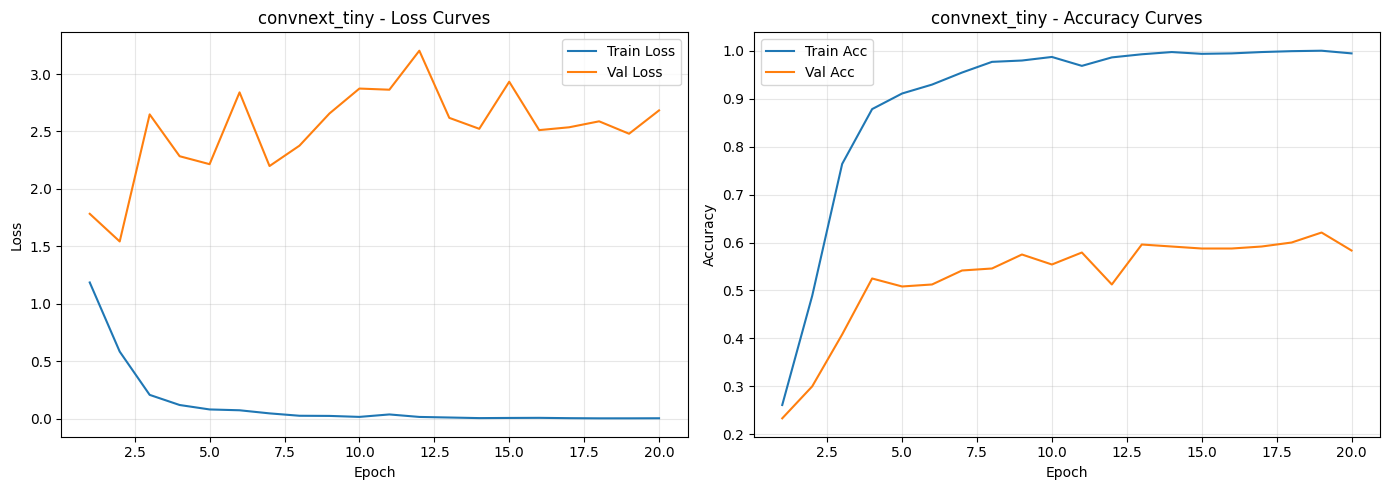

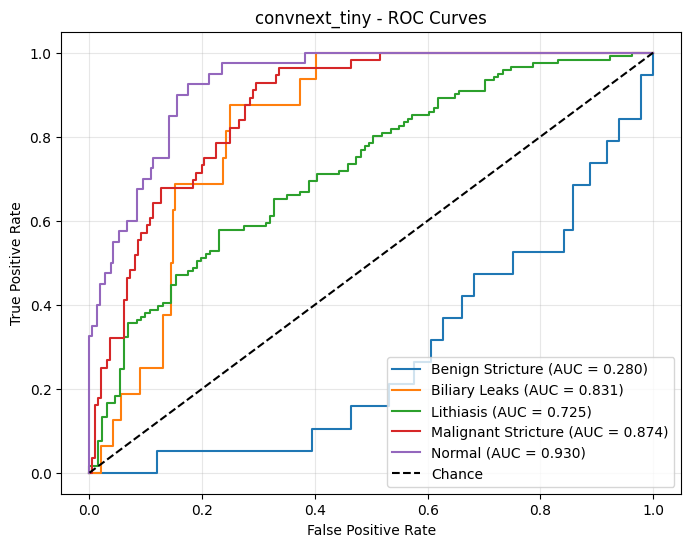


Starting benchmark for efficientnet_v2_s

=== efficientnet_v2_s architecture ===
EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): 

efficientnet_v2_s | Epoch 01 | Train Loss: 0.9503 | Train Acc: 0.3634 | Val Loss: 1.5362 | Val Acc: 0.2500 | Val Macro F1: 0.0999


efficientnet_v2_s | Epoch 02 | Train Loss: 0.3710 | Train Acc: 0.6366 | Val Loss: 1.5445 | Val Acc: 0.3125 | Val Macro F1: 0.2391


efficientnet_v2_s | Epoch 03 | Train Loss: 0.2656 | Train Acc: 0.7361 | Val Loss: 1.4128 | Val Acc: 0.3625 | Val Macro F1: 0.2801


efficientnet_v2_s | Epoch 04 | Train Loss: 0.1425 | Train Acc: 0.8364 | Val Loss: 1.9461 | Val Acc: 0.3625 | Val Macro F1: 0.2738


...

efficientnet_v2_s | Epoch 06 | Train Loss: 0.1250 | Train Acc: 0.8875 | Val Loss: 1.2567 | Val Acc: 0.5750 | Val Macro F1: 0.4645


efficientnet_v2_s | Epoch 07 | Train Loss: 0.0729 | Train Acc: 0.9322 | Val Loss: 2.1228 | Val Acc: 0.5292 | Val Macro F1: 0.3355


efficientnet_v2_s | Epoch 08 | Train Loss: 0.0536 | Train Acc: 0.9433 | Val Loss: 2.1946 | Val Acc: 0.5625 | Val Macro F1: 0.3534


efficientnet_v2_s | Epoch 09 | Train Loss: 0.0404 | Train Acc: 0.9638 | Val Loss: 2.2249 | Val Acc: 0.5500 | Val Macro F1: 0.3370


efficientnet_v2_s | Epoch 10 | Train Loss: 0.0282 | Train Acc: 0.9740 | Val Loss: 1.8785 | Val Acc: 0.5583 | Val Macro F1: 0.3700
Early stopping for efficientnet_v2_s at epoch 10


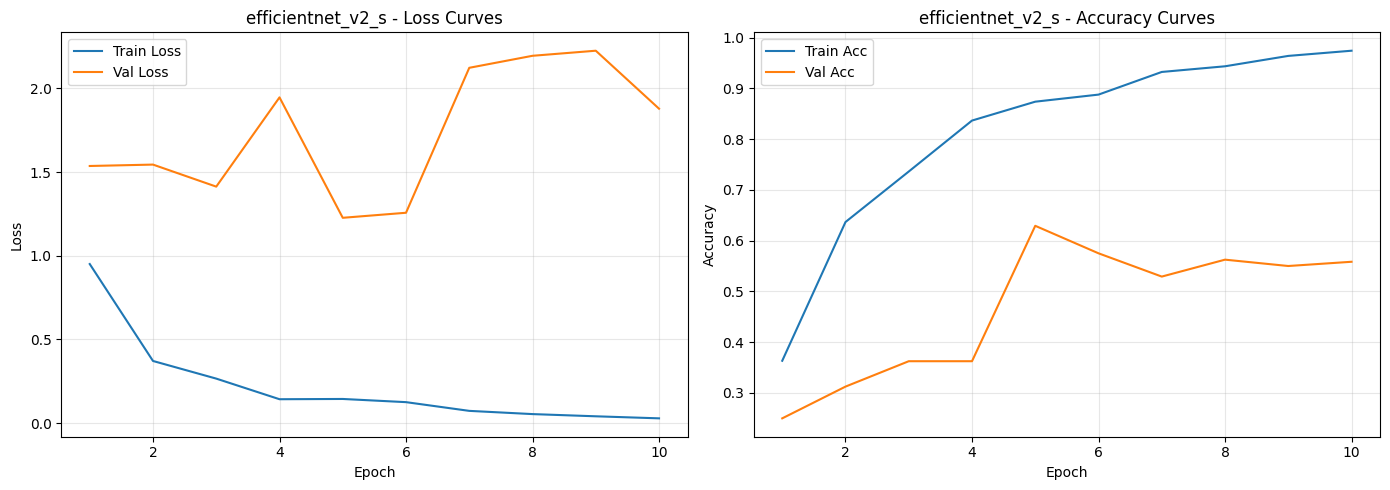

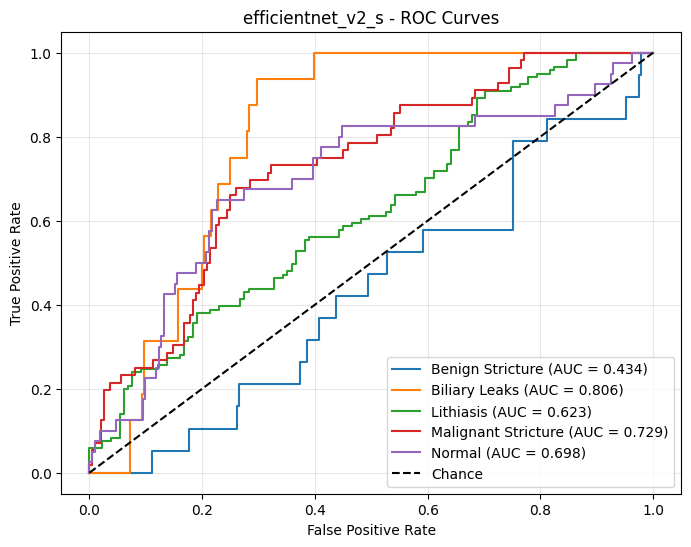


Starting benchmark for resnet50

=== resnet50 architecture ===
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequenti

resnet50 | Epoch 01 | Train Loss: 1.0297 | Train Acc: 0.2928 | Val Loss: 1.6922 | Val Acc: 0.2375 | Val Macro F1: 0.0789


resnet50 | Epoch 02 | Train Loss: 0.4641 | Train Acc: 0.5019 | Val Loss: 1.5404 | Val Acc: 0.2958 | Val Macro F1: 0.1865


resnet50 | Epoch 03 | Train Loss: 0.3273 | Train Acc: 0.6924 | Val Loss: 1.6941 | Val Acc: 0.2792 | Val Macro F1: 0.2221


resnet50 | Epoch 04 | Train Loss: 0.1724 | Train Acc: 0.7686 | Val Loss: 1.6877 | Val Acc: 0.3083 | Val Macro F1: 0.2679


...

resnet50 | Epoch 06 | Train Loss: 0.1032 | Train Acc: 0.8857 | Val Loss: 2.4425 | Val Acc: 0.4167 | Val Macro F1: 0.3004


resnet50 | Epoch 07 | Train Loss: 0.0725 | Train Acc: 0.9108 | Val Loss: 2.4464 | Val Acc: 0.5083 | Val Macro F1: 0.3357


resnet50 | Epoch 08 | Train Loss: 0.0609 | Train Acc: 0.9275 | Val Loss: 2.6359 | Val Acc: 0.5042 | Val Macro F1: 0.3442


resnet50 | Epoch 09 | Train Loss: 0.0376 | Train Acc: 0.9619 | Val Loss: 2.4746 | Val Acc: 0.5458 | Val Macro F1: 0.3659


resnet50 | Epoch 10 | Train Loss: 0.0242 | Train Acc: 0.9786 | Val Loss: 2.4246 | Val Acc: 0.5708 | Val Macro F1: 0.4072
Early stopping for resnet50 at epoch 10


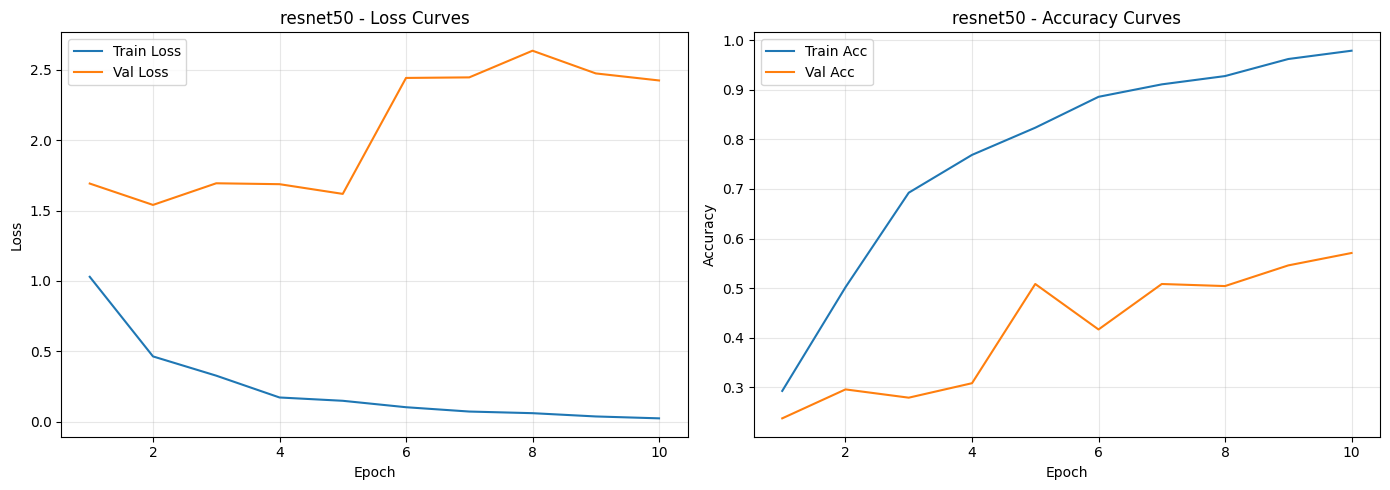

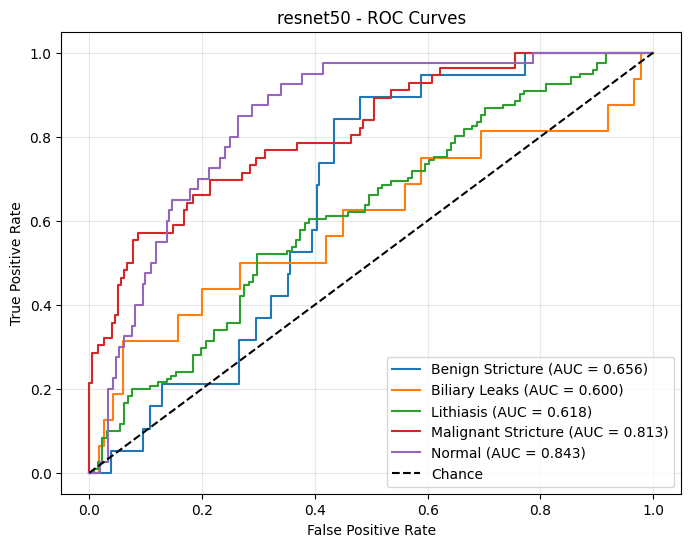


Starting benchmark for densenet121

=== densenet121 architecture ===
DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-

densenet121 | Epoch 01 | Train Loss: 0.7616 | Train Acc: 0.4071 | Val Loss: 1.5013 | Val Acc: 0.2792 | Val Macro F1: 0.2052


densenet121 | Epoch 02 | Train Loss: 0.2817 | Train Acc: 0.7175 | Val Loss: 1.5582 | Val Acc: 0.3625 | Val Macro F1: 0.2742


densenet121 | Epoch 03 | Train Loss: 0.1537 | Train Acc: 0.8160 | Val Loss: 1.6620 | Val Acc: 0.4375 | Val Macro F1: 0.3385


densenet121 | Epoch 04 | Train Loss: 0.1000 | Train Acc: 0.9043 | Val Loss: 1.5813 | Val Acc: 0.5167 | Val Macro F1: 0.3857


...

densenet121 | Epoch 09 | Train Loss: 0.0233 | Train Acc: 0.9758 | Val Loss: 2.3642 | Val Acc: 0.5292 | Val Macro F1: 0.3495


densenet121 | Epoch 10 | Train Loss: 0.0280 | Train Acc: 0.9749 | Val Loss: 2.3176 | Val Acc: 0.5583 | Val Macro F1: 0.3736


densenet121 | Epoch 11 | Train Loss: 0.0287 | Train Acc: 0.9814 | Val Loss: 2.3085 | Val Acc: 0.5250 | Val Macro F1: 0.3701


densenet121 | Epoch 12 | Train Loss: 0.0212 | Train Acc: 0.9805 | Val Loss: 2.2756 | Val Acc: 0.5292 | Val Macro F1: 0.3774


densenet121 | Epoch 13 | Train Loss: 0.0096 | Train Acc: 0.9954 | Val Loss: 2.3682 | Val Acc: 0.5542 | Val Macro F1: 0.3762
Early stopping for densenet121 at epoch 13


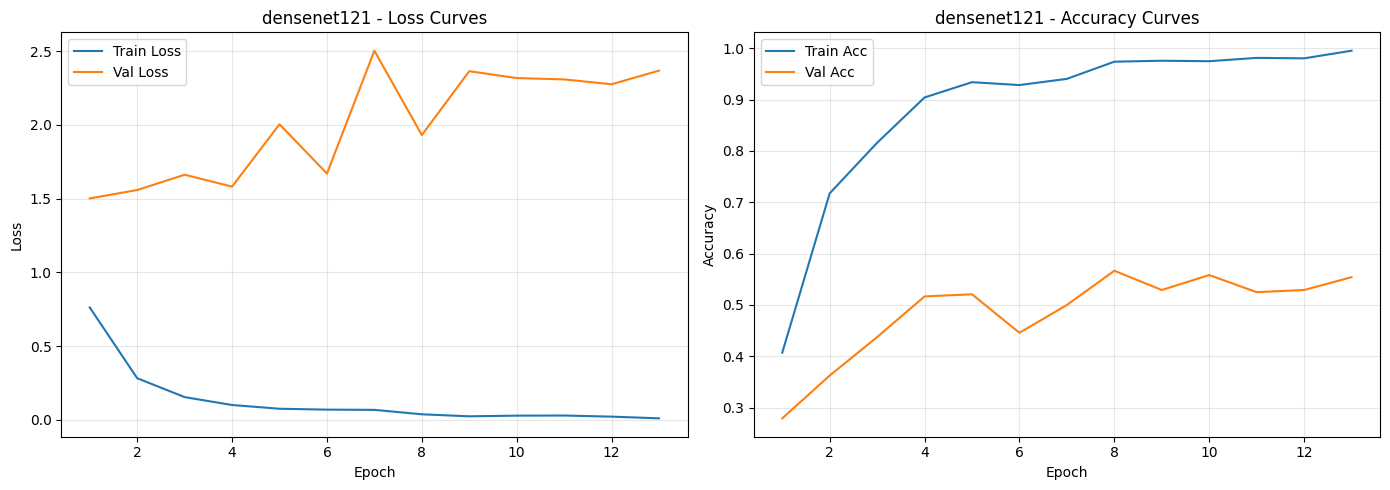

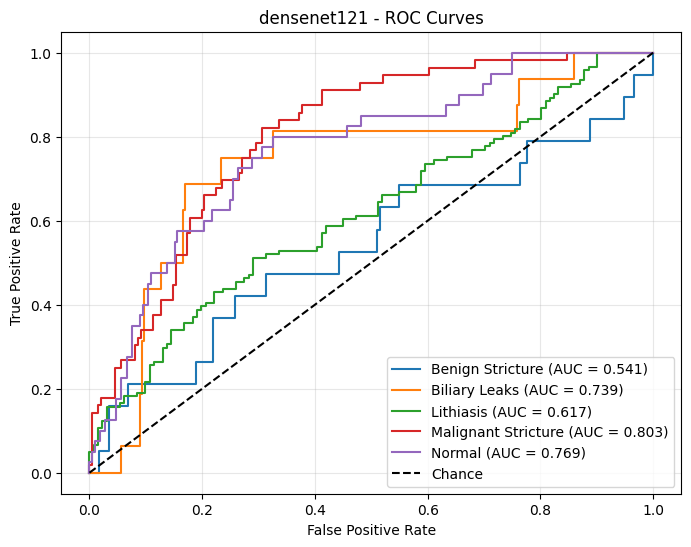

,model_name,best_epoch,best_val_macro_f1,test_accuracy,test_balanced_accuracy,test_macro_f1,test_macro_precision,test_macro_recall,test_roc_auc_ovo_macro,test_pr_auc_macro,test_loss
0,convnext_tiny,19,0.420008,0.587302,0.425446,0.395575,0.382532,0.425446,0.727874,0.455574,3.629352
3,densenet121,8,0.396403,0.472222,0.343194,0.299300,0.277360,0.343194,0.693946,0.361464,2.514856
2,resnet50,5,0.408282,0.448413,0.368533,0.312768,0.305576,0.368533,0.705859,0.377073,2.130380
1,efficientnet_v2_s,5,0.502591,0.420635,0.336257,0.297757,0.289052,0.336257,0.657997,0.317042,2.285532


In [31]:
benchmark_results = []
for model_name in MODEL_NAMES:
    print(f'\nStarting benchmark for {model_name}')
    result = train_model(model_name, train_loader, val_loader, class_names, device, RESULTS_DIR, MODELS_DIR)
    benchmark_results.append(result)

benchmark_results_df = pd.DataFrame(benchmark_results)
benchmark_results_df = benchmark_results_df.sort_values(by='test_accuracy', ascending=False)
summary_path = os.path.join(RESULTS_DIR, 'benchmark_summary.csv')
benchmark_results_df.to_csv(summary_path, index=False)
benchmark_results_df